## **Utilización de keras para reconocimiento de dígitos manuscritos**

Datos de partida: utilizaremos el dataset **MNIST, recopilado y compartido por Yann LeCun** y que podemos cargar desde la propia librería de Keras.


El reconocimiento de dígitos manuscritos con Keras se puede realizar en los siguientes pasos:

1. **Instalación de Dependencias.**

2. **Importar Librerias.**

3. **Cargar los datos:** Obtener un conjunto de datos de imágenes de dígitos manuscritos y etiquetarlos con sus correspondientes números.

4. **Preprocesamiento:** Normalizar y procesar las imágenes para asegurarse de que sean compatibles con la red neuronal.

5. **Creación de la red neuronal:** Crear una red neuronal de tipo convolutional neural network (CNN) en Keras, especificando la arquitectura de la red y la función de pérdida.

6. **Entrenamiento:** Entrenar la red neuronal con el conjunto de datos de imágenes etiquetadas para que pueda aprender a clasificar dígitos manuscritos.

7. **Evaluación:** Evaluar el desempeño de la red neuronal en un conjunto de datos de prueba para determinar su capacidad de reconocimiento de dígitos manuscritos.

8. **Uso:** Utilizar la red neuronal entrenada para hacer predicciones de dígitos manuscritos en imágenes nuevas.

---
### **1. Instalación de Dependencias**


In [1]:
!pip install tensorflow
!pip install numpy
!pip install matplotlib
!pip install keras


---
### **2. Importar Librerias**


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

---
### **3. Cargar los Datos**

**Cargar el dataset MNIST.**

El dataset MNIST viene incluido en Keras, así que lo podemos cargar directamente.

En este caso, estamos cargando el dataset en dos partes:
1. El conjunto de entrenamiento (x_train, y_train)

2. El conjunto de prueba (x_test, y_test).

**Importante:**

**x_train y x_test contienen imágenes de dígitos manuscritos, mientras que y_train y y_test contienen las etiquetas** que corresponden a cada imagen.

* Por ejemplo, **si la imagen es un "7", su etiqueta será "7").**


Por tanto, empezariamos por importar el dataset desde la librería Keras y cargarlo con el método **load_data()**




In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Vamos a ver la estructura de los conjuntos de datos.**

In [4]:
print(f'Datasets de entrenamientos:\ Imagenes: {x_train.shape}. Etiquetas: {y_train.shape}')
print("---------------------")
print(f'Datasets de test:\ Imagenes: {x_test.shape}. Etiquetas: {y_test.shape}')

Datasets de entrenamientos:\ Imagenes: (60000, 28, 28). Etiquetas: (60000,)
---------------------
Datasets de test:\ Imagenes: (10000, 28, 28). Etiquetas: (10000,)


**Vamos a ver una de las imágenes y saber como vienen representados los datos**

In [5]:
print(f'Imagen cargada en la posición 0:\n {x_train[0]}')


Imagen cargada en la posición 0:
 [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0 

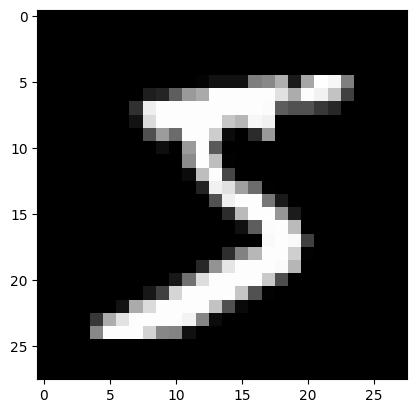

In [6]:
plt.imshow(.x_train[0]reshape(28, 28), cmap='gray')

In [7]:
print(f'Label asociada a la imagen de la posición 0:\n {y_train[0]}')

Label asociada a la imagen de la posición 0:
 5


### **4. Preprocesamiento**

#### 4.1 **Preparando las imágenes**

Antes de entrenar la red neuronal, es necesario **preprocesar los datos.**

* En este caso, **estamos normalizando los valores de las imágenes** (dividiéndolos por 255.0), para que todos los valores estén en un rango entre 0 y 1.

* También estamos **cambiando la forma de las imágenes para que sean aceptables** por la red neuronal (en este caso, 28x28x1).



In [8]:
x_train = x_train.reshape(x_train.shape[0], 28*28)
x_test = x_test.reshape(x_test.shape[0], 28*28)

x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

In [9]:
print(x_train.shape[0])
print(x_test.shape[0])

60000
10000


#### 4.2 **Preparando las Etiquetas - one-hot encoding.**

También va a ser necesario pasar las etiquetas a tipo "categórico".
Tentremos 10 categorias, una por cada valor numérico, de manera que se activaran a 1 cuando la imagen represente esa posición y 0 cuando no. A esta técnica se la denomina **one-hot encoding.**



In [10]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [11]:
'''ahora la etiqueta no muestra el valor, sino un 1 ó 0(True/False)
1 cuando la imagen se corresponde con el número de esa posición y 0 cuando no
Por ejemplo. La imagen x_train[0] representa al 5, cuando miremos ahora el conjunto
con las etiquetas, y_train[0], deberia mostrar en la posición 5 un 1.
'''
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

### **5. Creación de la Red Neuronal**

1. Importamos los módulos para crear un modelo y para utilizar la arquitectura por capas típica del deep learning.

2. Creamos el **objeto network**, que **será nuestro modelo** de la clase **Sequential()**, que es la que admite varias capas de profundidad.

3. Después, con el método **add**, **iremos apilando capas**, en este caso, de la clase Dense, que son las de la arquitectura típica de red neuronal (densely connected).

4. Una primera capa tendrá el atributo de 10 neuronas y función de activación "sigmoid" y la siguiente capa tendrá 10 neuronas y función de activación "softmax"




In [12]:
from keras import models
from keras import layers

network = models.Sequential()
network.add(layers.Dense(10, activation = 'sigmoid', input_shape = (28*28,)))
network.add(layers.Dense(10, activation = 'softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1. Importamos los módulos necesarios para crear una red neuronal en Keras.

2. **network = models.Sequential()**
  
  * Crea una instancia de una red neuronal secuencial, que es un tipo de red neuronal feed-forward.

3. **network.add(layers.Dense(512, activation = 'relu', input_shape = (28*28,)))**
  * Agrega una capa densa (fully connected) a la red neuronal.
  * Esta capa tiene 512 neuronas y utiliza la función de activación ReLU (rectified linear unit).
  * La forma de entrada de la capa es (28 * 28,), lo que significa que la capa aceptará un vector de **784 elementos**. Las imágenes tienen 28 pixeles x 28 pixeles.

4. **network.add(layers.Dense(10, activation = 'softmax'))**
  * Agrega una capa densa adicional con 10 unidades y utiliza la función de activación softmax.
  * **La capa de salida se utiliza para la clasificación de 10 categorías.**

**En resumen:**

* <font color='blue'>Creamos una red neuronal feed-forward con dos capas densas, la primera con 512 neuronas y la segunda con 10.</font>

* <font color='blue'>La primera capa utiliza la función de activación ReLU y la segunda capa utiliza la función de activación softmax.</font>

In [ ]:
network.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 10)                7850      
                                                                 
 dense_5 (Dense)             (None, 10)                110       
                                                                 
Total params: 7960 (31.09 KB)
Trainable params: 7960 (31.09 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


#### **5.1 Fijar los parámetros del entrenamiento**

Antes de entrenar el modelo, es necesario compilarlo. En este paso, estamos especificando el optimizador que se utilizará, el tipo de función de coste (la relacionada con el error entre el resultado del modelo y las etiquetas dadas) y las métricas que se utilizarán para evaluar el modelo, que será 'accuracy' (precisión o casos correctamente clasificados).

In [ ]:
network.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

### **6. Entrenamiento del modelo**

Llegamos al paso culminante: **el entrenamiento del modelo.**

Se hace utilizando el método **fit()**, con los parámetros imprescindibles del conjunto de datos de entrada, el número de iteraciones de cálculo, y el tamaño del lote de datos a utilizar en cada iteración.




In [ ]:
history = network.fit(x_train, y_train, batch_size=128, epochs=5)

Epoch 1/5
469/469 [==============================] - 3s 3ms/step - loss: 2.2174 - accuracy: 0.2485
Epoch 2/5
469/469 [==============================] - 1s 3ms/step - loss: 1.9789 - accuracy: 0.5840
Epoch 3/5
469/469 [==============================] - 1s 3ms/step - loss: 1.7758 - accuracy: 0.6432
Epoch 4/5
469/469 [==============================] - 2s 4ms/step - loss: 1.5978 - accuracy: 0.6697
Epoch 5/5
469/469 [==============================] - 1s 3ms/step - loss: 1.4459 - accuracy: 0.6951


### **7. Evaluación del modelo entrenado**

Ahora probamos el modelo entrenado utilizando el método evaluate() y los datos de test.



In [ ]:
score = network.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 1.366803526878357
Test accuracy: 0.7095000147819519


Podemos ver que se obtiene una precisión del 71% con los nuevos datos de test.
El Test loss es bastante elevado. El modelo se puede mejorar bastante.

### **8. Uso - Generación del Modelo Predictivo**

* En el ejemplo anterior, una vez que el modelo ha sido entrenado y evaluado, se pueden hacer **predicciones con los datos de prueba o con nuevos datos.**

* **Para hacer predicciones, se puede usar el método predict() del modelo**

In [ ]:
# Hacemos predicciones con el modelo
predicciones = network.predict(x_test)
predicciones

313/313 [==============================] - 1s 2ms/step


array([[0.03049994, 0.03583822, 0.0498217 , ..., 0.48536074, 0.03548702,
        0.11202784],
       [0.09534166, 0.16215296, 0.15849935, ..., 0.01813332, 0.07940175,
        0.03824931],
       [0.02862507, 0.39749035, 0.18541141, ..., 0.05154082, 0.05668565,
        0.05498302],
       ...,
       [0.03276082, 0.04393684, 0.05426956, ..., 0.1909743 , 0.09598608,
        0.19886   ],
       [0.125978  , 0.08162282, 0.06891363, ..., 0.06099438, 0.12813458,
        0.11643697],
       [0.05318298, 0.04224335, 0.07038652, ..., 0.0187466 , 0.07100875,
        0.04936168]], dtype=float32)

In [ ]:
diez = predicciones[:10]
diez

array([[0.03049994, 0.03583822, 0.0498217 , 0.05067018, 0.14882831,
        0.03167675, 0.01978926, 0.48536074, 0.03548702, 0.11202784],
       [0.09534166, 0.16215296, 0.15849935, 0.16227898, 0.02080644,
        0.11862881, 0.14650738, 0.01813332, 0.07940175, 0.03824931],
       [0.02862507, 0.39749035, 0.18541141, 0.0726737 , 0.04506471,
        0.03859573, 0.06892956, 0.05154082, 0.05668565, 0.05498302],
       [0.3424019 , 0.02200445, 0.019757  , 0.11114715, 0.06876161,
        0.14758176, 0.06413418, 0.0793051 , 0.06826963, 0.07663723],
       [0.05089797, 0.0391736 , 0.0596554 , 0.03422629, 0.30651873,
        0.0625046 , 0.07825015, 0.16974007, 0.06786736, 0.13116573],
       [0.02691507, 0.41718918, 0.16711123, 0.07317691, 0.04239615,
        0.0374637 , 0.04473902, 0.0525918 , 0.07020006, 0.06821684],
       [0.05570573, 0.03202034, 0.04847056, 0.0633868 , 0.23686649,
        0.0643354 , 0.04185705, 0.22034323, 0.08312108, 0.1538932 ],
       [0.06392002, 0.06934978, 0.0856008

En este código, **predicciones** contiene las predicciones del modelo para cada imagen en x_test.

 Cada predicción es un vector de 10 elementos, cada uno representando la probabilidad de que la imagen pertenezca a cada una de las 10 clases (dígitos del 0 al 9).

In [ ]:

# Convertimos las predicciones a etiquetas
predicciones = np.argmax(predicciones, axis=1)


* Se usa la función **np.argmax()** para convertir cada vector de probabilidades en una etiqueta única, que es el índice con la probabilidad máxima.

* Recordad que **argmax devuelve el índice del elemento mayor de al array.** Como tenemos un array de 10 elementos que representan cada uno un número del 0-9, el indice que devuelve argmax va a ser el Nº.

* Para visualizar las predicciones, se pueden mostrar las imágenes y sus respectivas etiquetas de forma gráfica, por ejemplo con la librería matplotlib:

In [ ]:
predicciones[:10]

array([7, 3, 1, 0, 4, 1, 4, 4, 6, 7])

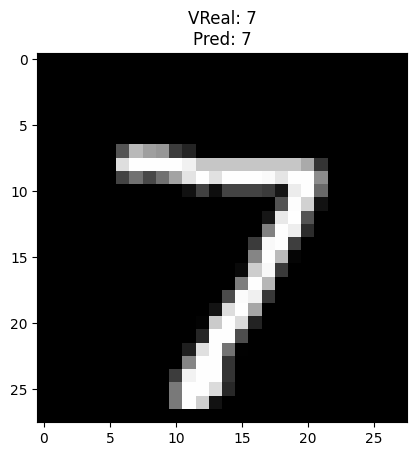

In [ ]:
# Mostramos una imagen y su respectiva etiqueta
plt.imshow(x_test[0].reshape(28, 28), cmap='gray')
plt.title(f'VReal: {np.argmax(y_test[0])}\nPred: {predicciones[0]}')
plt.show()

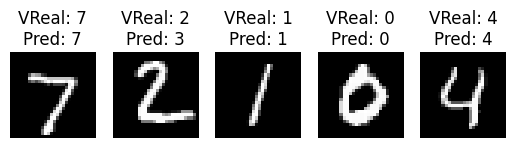

In [ ]:
# Mostramos varias imágenes y sus respectivas etiquetas
for i in range(5):
    plt.subplot(1, 5, i + 1 )
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f'VReal: {np.argmax(y_test[i])}\nPred: {predicciones[i]}')
    plt.axis('off')
plt.show()

### **Puedes mejorar la precisión del modelo???** 💪💪💪💪